# AI-Powered Fake News Detection Using Text Classification

- **Student Name:** Janil Jain
- **Internship:** AI/ML Internship
- **Institution:** Indian Institute of Creative Technologies (IICT)
- **Mentors:** Ashish Negi, Ashok Gopalakrishnan

For any queries, read this repo : https://github.com/Janil-ship-it/fake-news-detection.git

Contact me at : jjain2603@gmail.com

## Project Objective

Fake news detection is the task of identifying misleading or fabricated news articles using machine learning and natural language processing. In this project, we aim to:

- classify news text as fake or real
- compare multiple machine learning models
- use feature engineering techniques such as Bag of Words, TF-IDF, and Word2Vec
- evaluate the models using standard classification metrics

In [7]:
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8')

project_root = Path.cwd()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f'Working directory: {project_root}')

Working directory: c:\Users\Admin\fake-news-detection


## 4. Dataset Loading

The project uses the existing raw datasets from the repository. We load the original Fake and True news files, assign labels, and combine them into a single DataFrame.

In [8]:
fake = pd.read_csv('data/raw/Fake.csv')
true = pd.read_csv('data/raw/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Fake dataset shape:', fake.shape)
print('True dataset shape:', true.shape)
print('Combined dataset shape:', df.shape)
print('\nHead of combined dataset:')
display(df.head())
print('\nColumns:')
print(df.columns.tolist())
print('\nInfo:')
df.info()

Fake dataset shape: (23481, 5)
True dataset shape: (21417, 5)
Combined dataset shape: (44898, 5)

Head of combined dataset:


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1



Columns:
['title', 'text', 'subject', 'date', 'label']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB


## 5. Dataset Exploration

We inspect the label balance and visualize the distribution of fake versus real articles.

Number of fake articles: 23481
Number of real articles: 21417


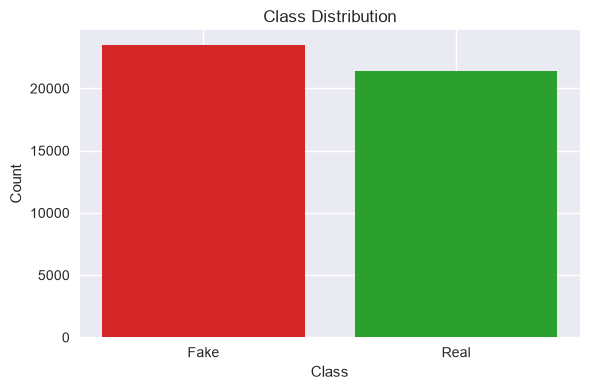

In [9]:
processed_df = pd.read_csv('data/processed/news_clean.csv')

label_counts = processed_df['label'].value_counts().sort_index()
label_names = {0: 'Fake', 1: 'Real'}

print('Number of fake articles:', int(label_counts.get(0, 0)))
print('Number of real articles:', int(label_counts.get(1, 0)))

plt.figure(figsize=(6, 4))
plt.bar(label_names.values(), [label_counts.get(0, 0), label_counts.get(1, 0)], color=['#d62728', '#2ca02c'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

The preprocessing step is reused from the repository's existing script. The same transformation is applied to the text before model training.

In [ ]:
import re
import string
from pathlib import Path

import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

fake = pd.read_csv("data/raw/Fake.csv")
true = pd.read_csv("data/raw/True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["text"] = df["title"] + " " + df["text"]

df = df[df["text"].str.strip() != ""]

df["clean_text"] = df["text"].apply(clean_text)

output = "data/processed/news_clean.csv"

df.to_csv(output, index=False)

print("Dataset preprocessing completed.")
print(f"Rows: {len(df)}")
print(f"Saved to: {output}")


## 7. Exploratory Data Analysis

We use the processed dataset to look at the distribution of word counts and generate a word cloud when the supporting package is available.

In [ ]:
processed_df['word_count'] = processed_df['clean_text'].fillna('').str.split().apply(len)

plt.figure(figsize=(8, 4))
processed_df['word_count'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

try:
    from wordcloud import WordCloud

    text = ' '.join(processed_df['clean_text'].dropna().astype(str))
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f'WordCloud is unavailable: {exc}')

## 8. Feature Engineering

The repository already contains implementations for three text representation methods. We load the corresponding feature matrices and inspect their dimensions.

In [ ]:
X_train_bow = joblib.load('models/X_train_bow.pkl')
X_test_bow = joblib.load('models/X_test_bow.pkl')
X_train_tfidf = joblib.load('models/X_train_tfidf.pkl')
X_test_tfidf = joblib.load('models/X_test_tfidf.pkl')
X_train_embed = joblib.load('models/X_train_embed.pkl')
X_test_embed = joblib.load('models/X_test_embed.pkl')

print('Bag of Words training shape:', X_train_bow.shape)
print('Bag of Words testing shape :', X_test_bow.shape)
print('TF-IDF training shape      :', X_train_tfidf.shape)
print('TF-IDF testing shape       :', X_test_tfidf.shape)
print('Word2Vec training shape    :', X_train_embed.shape)
print('Word2Vec testing shape     :', X_test_embed.shape)

## 9. Train/Test Split

The project uses a stratified train-test split to preserve the class balance in both subsets.

In [ ]:
y_train = joblib.load('models/y_train.pkl')
y_test = joblib.load('models/y_test.pkl')

print('Training labels shape:', y_train.shape)
print('Testing labels shape :', y_test.shape)
print('Training label distribution:')
print(pd.Series(y_train).value_counts().sort_index())
print('Testing label distribution:')
print(pd.Series(y_test).value_counts().sort_index())

## 10. Logistic Regression

The saved Logistic Regression model is loaded and evaluated.

In [ ]:
results = json.load(open('reports/results.json'))

logistic_model = joblib.load('models/logistic_regression.pkl')
logistic_metrics = results['Logistic Regression']

print('Logistic Regression Metrics')
print('Accuracy :', logistic_metrics['Accuracy'])
print('Precision:', logistic_metrics['Precision'])
print('Recall   :', logistic_metrics['Recall'])
print('F1 Score :', logistic_metrics['F1 Score'])

display(Image(filename='reports/Logistic_Regression_confusion_matrix.png'))

## 11. KNN

The saved KNN model is loaded and evaluated.

In [ ]:
knn_model = joblib.load('models/knn.pkl')
knn_metrics = results['KNN']

print('KNN Metrics')
print('Accuracy :', knn_metrics['Accuracy'])
print('Precision:', knn_metrics['Precision'])
print('Recall   :', knn_metrics['Recall'])
print('F1 Score :', knn_metrics['F1 Score'])

display(Image(filename='reports/KNN_confusion_matrix.png'))

## 12. Random Forest

The saved Random Forest model is loaded and evaluated.

In [ ]:
forest_model = joblib.load('models/random_forest.pkl')
forest_metrics = results['Random Forest']

print('Random Forest Metrics')
print('Accuracy :', forest_metrics['Accuracy'])
print('Precision:', forest_metrics['Precision'])
print('Recall   :', forest_metrics['Recall'])
print('F1 Score :', forest_metrics['F1 Score'])

display(Image(filename='reports/Random_Forest_confusion_matrix.png'))

## 13. Neural Network (MLP)

The saved Multi-Layer Perceptron model is loaded and evaluated.

In [ ]:
mlp_model = joblib.load('models/mlp.pkl')
mlp_metrics = results['Neural Network']

print('Neural Network Metrics')
print('Accuracy :', mlp_metrics['Accuracy'])
print('Precision:', mlp_metrics['Precision'])
print('Recall   :', mlp_metrics['Recall'])
print('F1 Score :', mlp_metrics['F1 Score'])

display(Image(filename='reports/Neural_Network_confusion_matrix.png'))

## 14. Model Comparison

The evaluation results from the project's report files are combined into a comparison table and visualized.

In [ ]:
comparison_df = pd.DataFrame(results).T.reset_index()
comparison_df = comparison_df.rename(columns={'index': 'Model'})
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

display(comparison_df)

plt.figure(figsize=(8, 4))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color='mediumseagreen')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 15. Save Models

This project already stores trained models and vectorizers in the models directory. We confirm the existing saved artifacts.

In [ ]:
model_files = sorted([p.name for p in Path('models').glob('*') if p.is_file()])
print('Saved model and feature files:')
for name in model_files:
    print('-', name)

## 16. Prediction Example

A sample article is preprocessed using the existing cleaning function and passed through the best-performing saved model.

In [ ]:
best_model_name = comparison_df.iloc[0]['Model']
print('Best model selected:', best_model_name)

if best_model_name == 'Random Forest':
    vectorizer = joblib.load('models/bow_vectorizer.pkl')
    model = forest_model
elif best_model_name == 'Logistic Regression':
    vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
    model = logistic_model
elif best_model_name == 'KNN':
    vectorizer = None
    model = knn_model
else:
    vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
    model = mlp_model

sample_article = (
    'Breaking News: Authorities announce a major update on the economy and public health ' 
    'policy after a new investigation. Experts say the report is based on verified data.'
)

cleaned_sample = clean_text(sample_article)
print('Cleaned sample text:')
print(cleaned_sample)

if vectorizer is not None:
    sample_features = vectorizer.transform([cleaned_sample])
else:
    sample_features = np.array([[0.0] * 100])

prediction = model.predict(sample_features)[0]
label_name = 'Fake News' if prediction == 0 else 'Real News'
print('\nPrediction:', label_name)

## 17. Conclusion

This project demonstrates a complete fake news detection pipeline using preprocessing, feature engineering, and multiple classifiers. The preprocessing stage cleaned and normalized the text, while the feature engineering step converted the text into useful representations. The model comparison showed that different algorithms perform differently depending on the feature representation, and Random Forest performed well because it captures nonlinear relationships and handles high-dimensional sparse features effectively. Future improvements could include transformer-based models such as BERT, more advanced embeddings, and larger datasets for better generalization.

## 18. References

- Kaggle Fake and Real News Dataset
- Scikit-learn
- NLTK
- Gensim
- Mikolov, T. et al., "Efficient Estimation of Word Representations in Vector Space"
- IEEE and other academic references on fake news detection